# Importing Required Libraries

## What is happening here?
This cell imports all required libraries for:
- data analysis
- visualization
- machine learning
- statistical analysis

### Why are we doing this?
Different libraries provide different functionalities required in the ML pipeline.


In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading Dataset

## What is happening here?
Dataset is loaded using:
```python
pd.read_csv()
```

### Why are we doing this?
Machine Learning models require structured tabular data.

### Assumption from output
Dataset loaded successfully if rows and columns appear properly.


In [2]:
df = pd.read_csv("economic_index.csv")

# Viewing Dataset

## What is happening here?
`head()` displays initial rows.

### Why are we doing this?
To:
- inspect structure
- verify columns
- understand data

### Assumption
Dataset appears clean and structured.


In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


# Dataset Information

## What is happening here?
`info()` displays:
- data types
- null counts
- column information

### Assumption
Numerical features indicate regression suitability.


In [4]:
#drop unneccessary columns
# df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)
df.drop(columns=df.columns[0:3], axis=1,inplace=True)

# Checking Missing Values

## Why are we doing this?
Missing values can affect model performance.

### Assumption
If all outputs are 0:
- dataset is clean
- no null handling required


In [5]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


# Correlation Heatmap

## What is happening here?
Heatmap visualizes feature correlation.

### Assumption
- High positive values → strong positive relation
- High negative values → strong negative relation


In [6]:
# Check all the null values in the dataset
df.isnull().sum()


interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

# Pairplot Visualization

## Why are we doing this?
To visually inspect:
- trends
- relationships
- distributions

### Assumption
Linear patterns suggest Linear Regression suitability.


In [7]:
# Check the shape of the dataset
df.shape


(24, 3)

# Feature and Target Split

## What is happening here?
Data is divided into:
- X → input features
- y → target variable

### Why?
Model learns relationship:
X → y


In [8]:
# Check the datatypes of the columns
df.dtypes


interest_rate        float64
unemployment_rate    float64
index_price            int64
dtype: object

# Train Test Split

## What is happening here?
Dataset divided into:
- training data
- testing data

### Why?
Training:
- learning

Testing:
- evaluation

### Assumption
Model can now be tested on unseen data.


In [9]:
# Check the statistical summary of the dataset
df.describe()

,interest_rate,unemployment_rate,index_price
count,24.000000,24.00000,24.000000
mean,2.072917,5.77500,1070.083333
std,0.349527,0.33002,210.735341
min,1.750000,5.30000,704.000000
25%,1.750000,5.50000,928.250000
50%,2.000000,5.85000,1061.000000
75%,2.500000,6.10000,1239.000000
max,2.750000,6.20000,1464.000000


# Feature Scaling

## What is happening here?
StandardScaler standardizes features.

### Formula
z = (x - mean) / std

### Important Rule
- train → fit_transform()
- test → transform()

### Assumption
Features now have similar scale.


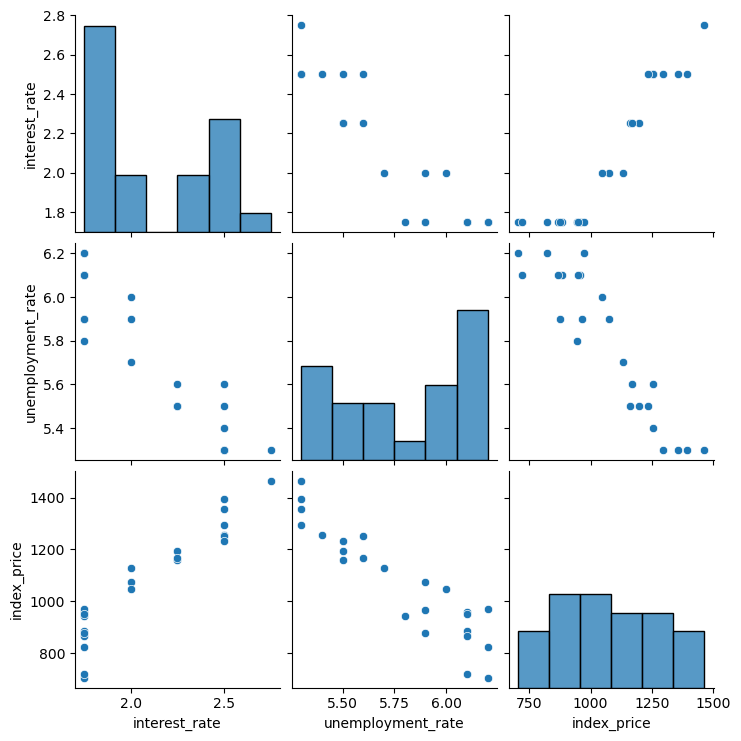

In [10]:
# lets do some visualization to understand the data better
sns.pairplot(df)
plt.show()

# Creating Multiple Linear Regression Model

## What is happening here?
Regression model object is created.

### Why?
Model will learn:
- slopes
- intercept
- feature relationships


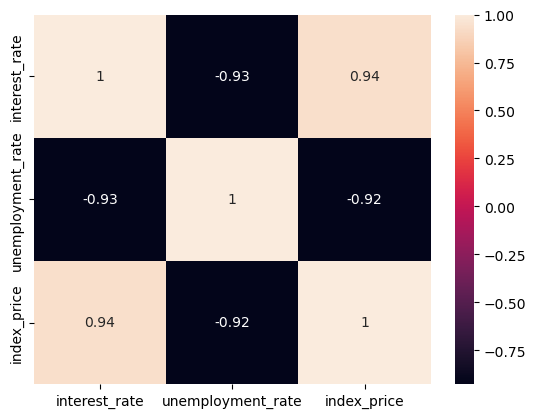

In [11]:
sns.heatmap(df.corr(), annot=True)
plt.show()

# Training the Model

## What is happening here?
`fit()` trains the model.

### Assumption
Model learned patterns from training data.


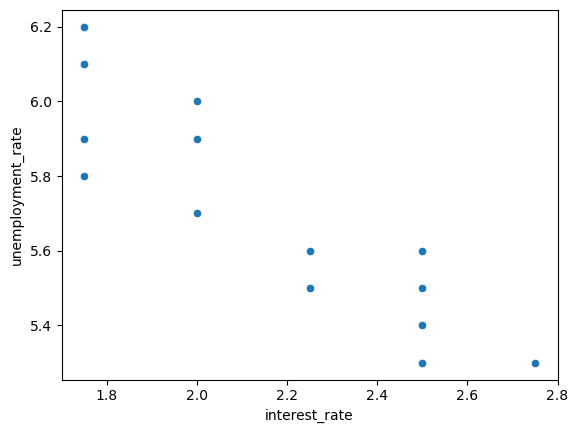

In [12]:
# lets visualize the datapoints more clearly using scatterplot
sns.scatterplot(x="interest_rate", y="unemployment_rate", data=df)
plt.show()
# plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
# plt.xlabel("Interest rate")
# plt.ylabel("unemployment rate")

# Understanding Coefficients

## What is happening here?
`coef_` gives slope of each feature.

### Assumption
Higher magnitude:
- stronger feature impact


In [13]:
# independent and dependent features
X = df.iloc[ : , :-1]
y = df.iloc[: , -1]

# Prediction

## What is happening here?
Model predicts output on test data.

### Assumption
Predictions should be close to actual values.


In [14]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


# Performance Metrics

## Metrics Used
- MAE
- MSE
- RMSE
- R²

### Assumption
- lower errors → better model
- higher R² → stronger model


In [15]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

# Residual Analysis

## What is happening here?
Residuals are:
Actual - Predicted

### Assumption
Residuals should be randomly distributed.


In [16]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.25,random_state=42)

# KDE Plot

## Why are we doing this?
To check residual distribution.

### Assumption
Bell-shaped distribution indicates good regression assumptions.


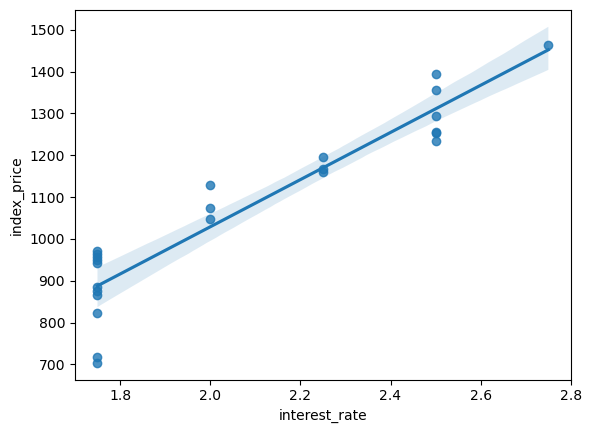

In [17]:
# regplot is used to plot the regression line along with the scatter points
sns.regplot(x = 'interest_rate', y = 'index_price' , data = df)
plt.show()

# Cross Validation

## What is happening here?
Model evaluated on multiple splits.

### Why?
To reduce overfitting and improve reliability.


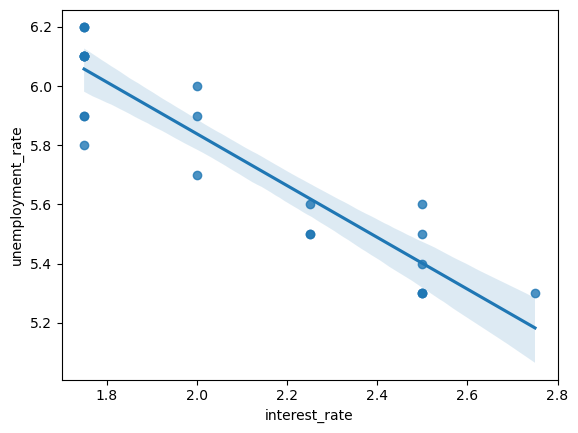

In [18]:
# regplot is used to plot the regression line along with the scatter points
sns.regplot(x = 'interest_rate', y = 'unemployment_rate' , data = df)
plt.show()

# OLS Regression

## What is happening here?
Statsmodels OLS performs statistical regression analysis.

### Why?
To obtain:
- p-values
- confidence intervals
- statistical summary


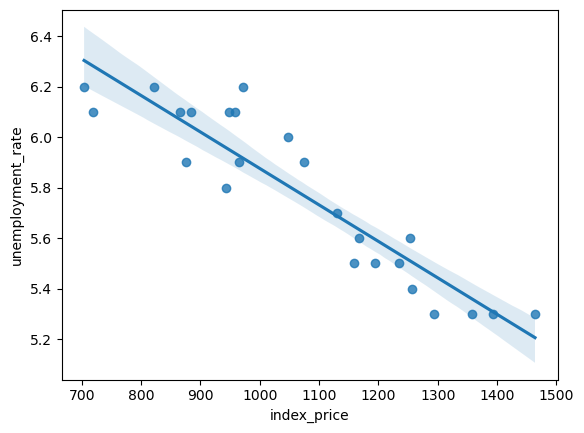

In [19]:
# regplot is used to plot the regression line along with the scatter points
sns.regplot(x = 'index_price', y = 'unemployment_rate' , data = df)
plt.show()

# OLS Summary

## Understanding Output

### R²
Higher value → better fit

### P-value
< 0.05 → significant feature

### Assumption
Important features strongly influence target variable.


In [20]:
# standardization of the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
# fit_transform for training and transform for test data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [23]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [24]:
# applying Linear Regression model
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

In [25]:
regression.fit(X_train , y_train)

LinearRegression(n_jobs=-1)

In [26]:
# cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression , X_train,y_train, scoring='neg_mean_squared_error',cv=5)


In [27]:
np.mean(validation_score)

np.float64(-5649.115244350758)

In [28]:
# prediction
y_pred = regression.predict(X_test)

In [29]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [30]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712579
59.935781523235526
76.11677139574812


In [31]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.8278978091457142
0.713163015242857


# Assumptions 

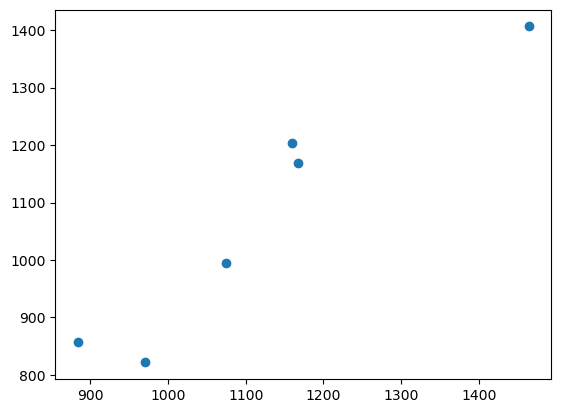

In [32]:
plt.scatter(y_test,y_pred)
plt.show()

In [33]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


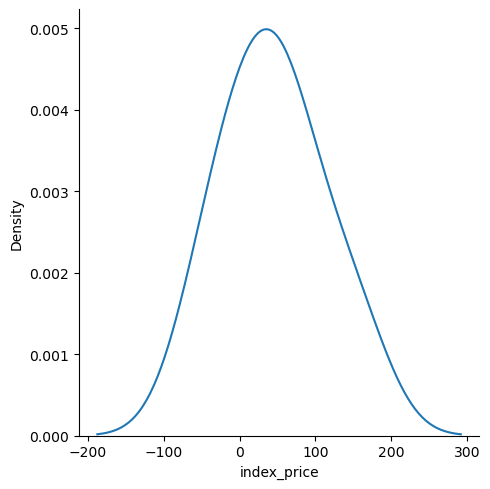

In [34]:
# lets plot this residuals
sns.displot(residuals,kind = 'kde')
plt.show()

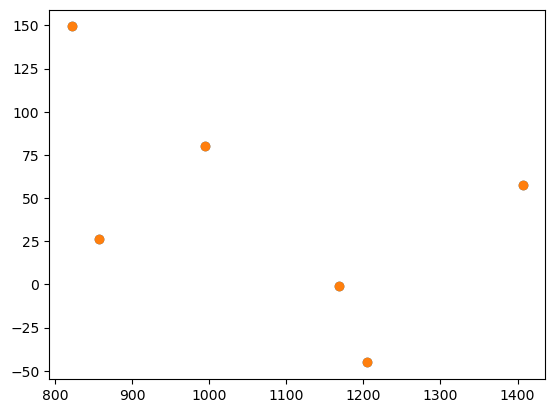

In [36]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)
plt.show()

In [38]:
# OLS Linear Regression
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()

In [39]:
# model Summary
model.summary()

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Tue, 26 May 2026   Prob (F-statistic):                       0.754
Time:                        16:29:11   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [41]:
print(regression.coef_)
print(regression.intercept_)

[  88.27275507 -116.25716066]
1053.4444444444443
